In [19]:
# =============================================================================
# Startup Investment Dataset – Train / Validation / Test Split
# Google Colab — runs from Google Drive
# =============================================================================
# PRE-REQUISITE:
#   Run DS22_ML_Data_Cleanup_And_EDA.ipynb first.
#   That script saves  investments_VC_clean.csv  to OUTPUT_DIR.
#   This script reads that clean file and produces:
#       train_set.csv      (70%)
#       validation_set.csv (15%)
#       test_set.csv       (15%)
# =============================================================================

# ── 0. Mount Drive & set paths ───────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

import os

# *** Edit this to match your Drive location (same folder used in EDA script) ***
OUTPUT_DIR = "/content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs"

CLEAN_DATA_PATH = f"{OUTPUT_DIR}/investments_VC_clean.csv"
TRAIN_PATH      = f"{OUTPUT_DIR}/train_set.csv"
VAL_PATH        = f"{OUTPUT_DIR}/validation_set.csv"
TEST_PATH       = f"{OUTPUT_DIR}/test_set.csv"

print(f"Reading clean data from      : {CLEAN_DATA_PATH}")
print(f"Train set will be saved      : {TRAIN_PATH}")
print(f"Validation set will be saved : {VAL_PATH}")
print(f"Test  set will be saved      : {TEST_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading clean data from      : /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/investments_VC_clean.csv
Train set will be saved      : /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/train_set.csv
Validation set will be saved : /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/validation_set.csv
Test  set will be saved      : /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/test_set.csv


In [20]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [21]:
# ── 2. Load clean dataset ─────────────────────────────────────────────────────
df = pd.read_csv(CLEAN_DATA_PATH)

print(f"Loaded dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget variable (status_code) distribution in full dataset:")
print(df["status_code"].value_counts().sort_index())
print(f"\n  (0 = closed | 1 = operating | 2 = acquired)")

Loaded dataset shape : 48,124 rows × 32 columns

Target variable (status_code) distribution in full dataset:
status_code
0     2603
1    41829
2     3692
Name: count, dtype: int64

  (0 = closed | 1 = operating | 2 = acquired)


In [22]:
# ── 3. Stratified Train / Validation / Test Split (70 / 15 / 15) ────────────
# We can't do a three-way split in one call, so we do it in two steps:
#   Step A: split full data → 70% train  |  30% temp
#   Step B: split temp      → 50% val    |  50% test  (= 15% / 15% of full)
# stratify is applied at both steps so class proportions are preserved
# throughout — critical for imbalanced targets.

# Step A — carve out the train set (70%)
train_set, temp_set = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["status_code"],
    shuffle=True,
)

# Step B — split the remaining 30% evenly into validation and test (15% each)
val_set, test_set = train_test_split(
    temp_set,
    test_size=0.50,
    random_state=42,
    stratify=temp_set["status_code"],
    shuffle=True,
)

print(f"Train      set : {len(train_set):,} rows  ({len(train_set)/len(df)*100:.1f}%)")
print(f"Validation set : {len(val_set):,} rows  ({len(val_set)/len(df)*100:.1f}%)")
print(f"Test       set : {len(test_set):,} rows  ({len(test_set)/len(df)*100:.1f}%)")

Train      set : 33,686 rows  (70.0%)
Validation set : 7,219 rows  (15.0%)
Test       set : 7,219 rows  (15.0%)


Class distribution (proportions):
             Full dataset  Train set  Validation set  Test set
status_code                                                   
closed               5.41       5.41            5.40      5.42
operating           86.92      86.92           86.92     86.91
acquired             7.67       7.67            7.67      7.67  (%)


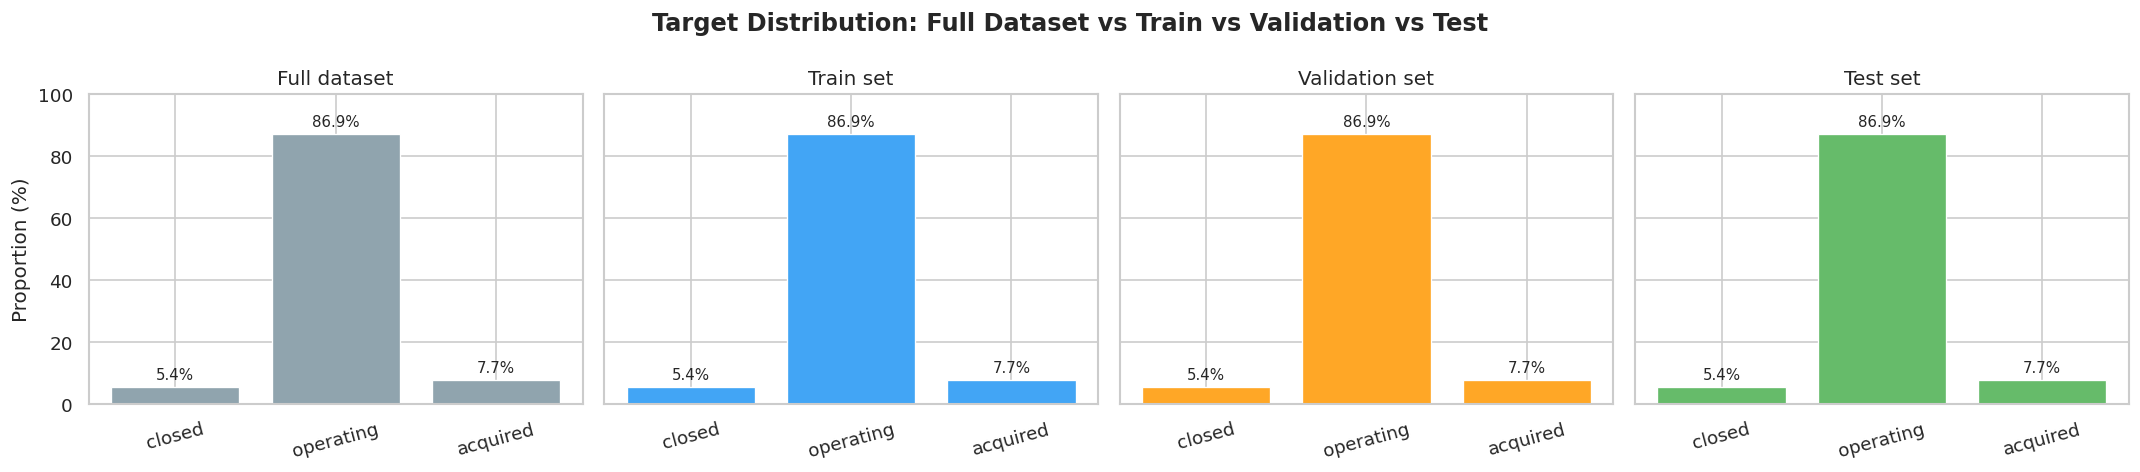


Plot saved → /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/split_target_distribution.png


In [23]:
# ── 4. Verify Class Distribution is Preserved ────────────────────────────────
LABELS = {0: "closed", 1: "operating", 2: "acquired"}

full_dist  = df["status_code"].value_counts(normalize=True).sort_index().rename("Full dataset")
train_dist = train_set["status_code"].value_counts(normalize=True).sort_index().rename("Train set")
val_dist   = val_set["status_code"].value_counts(normalize=True).sort_index().rename("Validation set")
test_dist  = test_set["status_code"].value_counts(normalize=True).sort_index().rename("Test set")

dist_report = pd.concat([full_dist, train_dist, val_dist, test_dist], axis=1)
dist_report.index = dist_report.index.map(LABELS)

print("Class distribution (proportions):")
print((dist_report * 100).round(2).to_string() + "  (%)")

# ── 4.1 Visual comparison ────────────────────────────────────────────────────
COLORS = ["#90a4ae", "#42a5f5", "#ffa726", "#66bb6a"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
fig.suptitle("Target Distribution: Full Dataset vs Train vs Validation vs Test", fontweight="bold")

for ax, (col, color) in zip(axes, zip(dist_report.columns, COLORS)):
    bars = ax.bar(dist_report.index, dist_report[col] * 100,
                  color=color, edgecolor="white", linewidth=0.8)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
    ax.set_title(col)
    ax.set_ylabel("Proportion (%)" if ax == axes[0] else "")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/split_target_distribution.png", bbox_inches="tight")
plt.show()
print(f"\nPlot saved → {OUTPUT_DIR}/split_target_distribution.png")

In [24]:
# ── 5. Save Train, Validation and Test Sets ──────────────────────────────────
train_set.to_csv(TRAIN_PATH, index=False)
val_set.to_csv(VAL_PATH,     index=False)
test_set.to_csv(TEST_PATH,   index=False)

print("=" * 60)
print("Split complete!")
print(f"  Train      set ({len(train_set):,} rows) → {TRAIN_PATH}")
print(f"  Validation set ({len(val_set):,} rows) → {VAL_PATH}")
print(f"  Test       set ({len(test_set):,} rows) → {TEST_PATH}")
print("=" * 60)
print("\nNext steps: fit preprocessing/imputation pipelines on the")
print("TRAIN SET only, then apply (transform) to all three sets.")

Split complete!
  Train      set (33,686 rows) → /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/train_set.csv
  Validation set (7,219 rows) → /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/validation_set.csv
  Test       set (7,219 rows) → /content/drive/My Drive/BIU DS 2025/ML Project - Startup Investements/startup_eda_outputs/test_set.csv

Next steps: fit preprocessing/imputation pipelines on the
TRAIN SET only, then apply (transform) to all three sets.
